In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

import pandas as pd

In [2]:
dataset = load_dataset("tanganke/gtsrb")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.52k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/224M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/109M [00:00<?, ?B/s]

data/contrast-00000-of-00001.parquet:   0%|          | 0.00/100M [00:00<?, ?B/s]

...

Generating jpeg_compression split:   0%|          | 0/12630 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/12630 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/12630 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/12630 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 26640
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    contrast: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    gaussian_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    impulse_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    jpeg_compression: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    motion_blur: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    pixelate: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    spatter: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
})


In [3]:
import pandas as pd

In [4]:
train = pd.DataFrame(dataset['train'])
test = pd.DataFrame(dataset['test'])

In [5]:
len(train)

26640

In [6]:
num_classes = len(train['label'].value_counts())

In [7]:
num_classes

43

In [10]:
train.label.value_counts()

,count
label,
1,1500
2,1500
13,1440
12,1410
38,1380
10,1350
4,1320
5,1260
25,1020


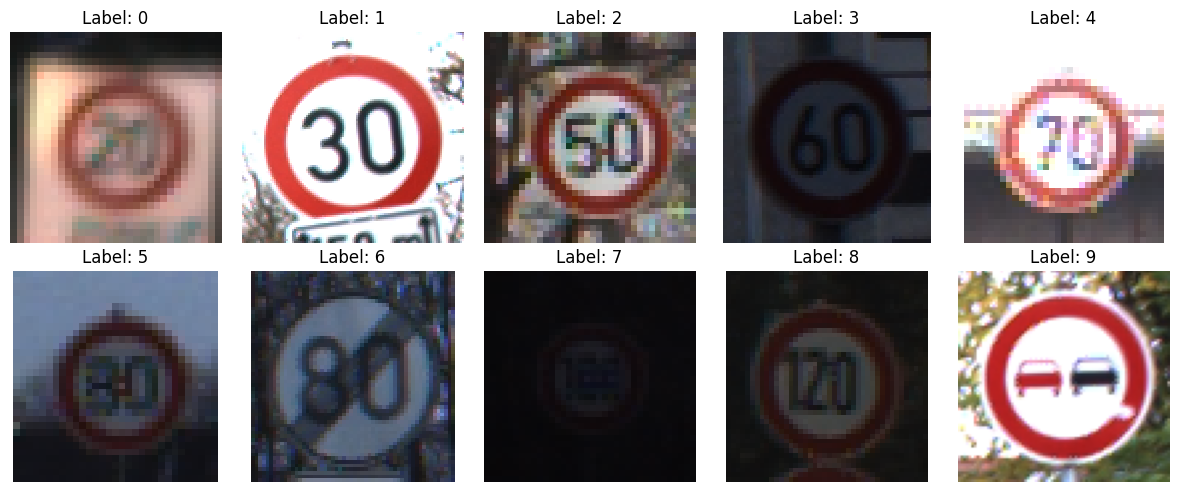

In [9]:
import random

# Select one random image for each label from 0 to 9
samples_to_plot = []
for i in range(10):
    # Filter dataset for the current label
    filtered_dataset = dataset['train'].filter(lambda example: example['label'] == i)
    if len(filtered_dataset) > 0:
        # Select a random sample from the filtered dataset
        random_index = random.randint(0, len(filtered_dataset) - 1)
        samples_to_plot.append(filtered_dataset[random_index])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, sample in zip(axes.flatten(), samples_to_plot):
    ax.imshow(sample["image"])
    ax.set_title(f"Label: {sample['label']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# reset index on the full dataset first
train = train.reset_index(drop=True)

train_df, val_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train['label']
)

# check overlap BEFORE resetting — use the original split indices
train_ids = set(train_df.index)
val_ids   = set(val_df.index)
print(len(train_ids & val_ids))

# then reset again after split
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test.reset_index(drop=True)

0


In [12]:
class GTSRBDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = self.df.loc[idx, 'image']
        label = int(self.df.loc[idx, 'label'])

        image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [13]:
temp_train_dataset = GTSRBDataset(
    train_df,
    transform=transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),])
)

temp_train_loader = DataLoader(
    temp_train_dataset,
    batch_size=256,
    shuffle=False
)

mean = torch.zeros(3)
std = torch.zeros(3)

for images, _ in temp_train_loader:
    mean += images.mean(dim=[0, 2, 3])
    std += images.std(dim=[0, 2, 3])

mean /= len(temp_train_loader)
std /= len(temp_train_loader)

final_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

train_dataset = GTSRBDataset(
    train_df,
    transform=final_transform
)

val_dataset = GTSRBDataset(
    val_df,
    transform=final_transform
)

test_dataset = GTSRBDataset(
    test_df,
    transform=final_transform
)

In [14]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([64, 3, 32, 32])
torch.Size([64])
tensor([16, 11,  2,  9, 13, 13, 14, 14,  3,  2])


In [16]:
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


def run_training(model, num_epochs, lr, name):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'\n{"─"*55}')
    print(f'  {name}')
    print(f'  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'{"─"*55}')

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = eval_epoch(model, val_loader,   criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        print(f'  Epoch {epoch:02d}/{num_epochs}  '
              f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  '
              f'val_acc={va_acc:.3f}')

    print(f'  Best val acc: {max(history["val_acc"])*100:.2f}%')
    return model, history

Using device: cuda


In [17]:
class MLP(nn.Module):
    def __init__(self, input_dim=3*32*32, num_classes=43):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)
class CNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            # block 1: 32x32 → 14x14
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # block 2: 14x14 → 7x7
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # block 3: 7x7, no pool
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

class CNNTunable(nn.Module):
    def __init__(self, dropout, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout * 0.75),  # slightly less dropout on second layer
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import os

# Create a dedicated folder in your Google Drive if it doesn't exist
save_dir = "/content/drive/MyDrive/my_models/"
os.makedirs(save_dir, exist_ok=True)


In [20]:

# Baseline model - MLP
mlp_model, mlp_history = run_training(MLP(), num_epochs=5, lr=1e-3, name='MLP Baseline')


───────────────────────────────────────────────────────
  MLP Baseline
  Params: 3,817,515
───────────────────────────────────────────────────────
  Epoch 01/5  train_loss=2.1118  train_acc=0.409  val_acc=0.673
  Epoch 02/5  train_loss=1.0626  train_acc=0.684  val_acc=0.810
  Epoch 03/5  train_loss=0.7452  train_acc=0.776  val_acc=0.875
  Epoch 04/5  train_loss=0.5278  train_acc=0.846  val_acc=0.933
  Epoch 05/5  train_loss=0.3891  train_acc=0.889  val_acc=0.942
  Best val acc: 94.22%


In [21]:
# Save the weights
torch.save(mlp_model.state_dict(), os.path.join(save_dir, "mlp_model.pt"))


In [22]:

# CNN
cnn_model, cnn_history = run_training(CNN(), num_epochs=5, lr=1e-3, name='CNN')


───────────────────────────────────────────────────────
  CNN
  Params: 1,956,331
───────────────────────────────────────────────────────
  Epoch 01/5  train_loss=2.7020  train_acc=0.210  val_acc=0.404
  Epoch 02/5  train_loss=1.1117  train_acc=0.619  val_acc=0.349
  Epoch 03/5  train_loss=0.3178  train_acc=0.894  val_acc=0.953
  Epoch 04/5  train_loss=0.0992  train_acc=0.969  val_acc=0.983
  Epoch 05/5  train_loss=0.0434  train_acc=0.988  val_acc=0.995
  Best val acc: 99.53%


In [80]:
# Hyperparameter Tuning
configs = [
    {'dropout': 0.3, 'lr': 1e-3},
    {'dropout': 0.4, 'lr': 1e-3},
    {'dropout': 0.4, 'lr': 5e-4},
    {'dropout': 0.4, 'lr': 3e-4},
    {'dropout': 0.5, 'lr': 3e-4},
]


tune_results = []
for cfg in configs:
    name  = f"dropout={cfg['dropout']}  lr={cfg['lr']}"
    model = CNNTunable(dropout=cfg['dropout'])
    _, h  = run_training(model, num_epochs=5, lr=cfg['lr'], name=name)
    tune_results.append({'config': cfg, 'best_val_acc': max(h['val_acc']), 'history': h})

print('\n=== Tuning Results ===')
for r in sorted(tune_results, key=lambda x: -x['best_val_acc']):
    print(f"  val_acc={r['best_val_acc']*100:.2f}%  dropout={r['config']['dropout']}  lr={r['config']['lr']}")


───────────────────────────────────────────────────────
  dropout=0.3  lr=0.001
  Params: 1,956,331
───────────────────────────────────────────────────────
  Epoch 01/5  train_loss=2.5107  train_acc=0.251  val_acc=0.420
  Epoch 02/5  train_loss=0.9264  train_acc=0.681  val_acc=0.732
  Epoch 03/5  train_loss=0.2180  train_acc=0.929  val_acc=0.962
  Epoch 04/5  train_loss=0.0574  train_acc=0.983  val_acc=0.984
  Epoch 05/5  train_loss=0.0228  train_acc=0.995  val_acc=0.996
  Best val acc: 99.57%

───────────────────────────────────────────────────────
  dropout=0.4  lr=0.001
  Params: 1,956,331
───────────────────────────────────────────────────────
  Epoch 01/5  train_loss=2.5520  train_acc=0.242  val_acc=0.406
  Epoch 02/5  train_loss=0.8376  train_acc=0.713  val_acc=0.777
  Epoch 03/5  train_loss=0.1977  train_acc=0.937  val_acc=0.965
  Epoch 04/5  train_loss=0.0589  train_acc=0.982  val_acc=0.992
  Epoch 05/5  train_loss=0.0254  train_acc=0.994  val_acc=0.996
  Best val acc: 99.62%


In [81]:
best_params=sorted(tune_results, key=lambda x: -x['best_val_acc'])[0]
print(best_params)

{'config': {'dropout': 0.4, 'lr': 0.001}, 'best_val_acc': 0.9962462462462462, 'history': {'train_loss': [2.551976550448764, 0.8376070865997681, 0.19774835129959267, 0.05885449429140524, 0.025428898101141146], 'train_acc': [0.24160097597597596, 0.7125093843843844, 0.9373123123123123, 0.9824042792792793, 0.9938532282282282], 'val_loss': [1.8292118930243872, 0.7630042449848072, 0.1032703631856778, 0.02626049818678035, 0.01386016063313853], 'val_acc': [0.4057807807807808, 0.777027027027027, 0.9649024024024024, 0.9924924924924925, 0.9962462462462462]}}


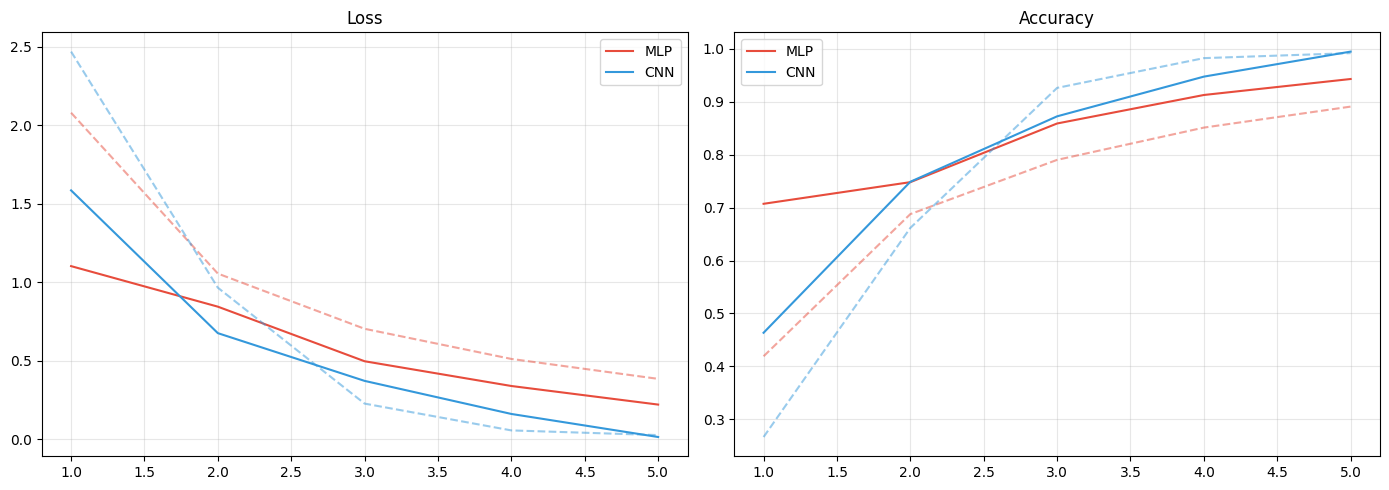


MLP test acc : 82.85%
CNN test acc : 94.93%


In [82]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h, name, c in zip(
    [mlp_history, cnn_history],
    ['MLP', 'CNN'],
    ['#E74C3C', '#3498DB']
):
    epochs = range(1, len(h['val_acc']) + 1)
    axes[0].plot(epochs, h['train_loss'], '--', color=c, alpha=0.5)
    axes[0].plot(epochs, h['val_loss'],   '-',  color=c, label=name)
    axes[1].plot(epochs, h['train_acc'],  '--', color=c, alpha=0.5)
    axes[1].plot(epochs, h['val_acc'],    '-',  color=c, label=name)

axes[0].set_title('Loss');     axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# final test accuracy
criterion = nn.CrossEntropyLoss()
_, mlp_test = eval_epoch(mlp_model, test_loader, criterion)
_, cnn_test = eval_epoch(cnn_model, test_loader, criterion)
print(f'\nMLP test acc : {mlp_test*100:.2f}%')
print(f'CNN test acc : {cnn_test*100:.2f}%')

In [26]:
cnn_model, cnn_history = run_training(CNNTunable(dropout=0.4), num_epochs=5, lr=5e-4, name='CNN')
torch.save(cnn_model.state_dict(), os.path.join(save_dir, "cnn_model.pt"))



───────────────────────────────────────────────────────
  CNN
  Params: 1,956,331
───────────────────────────────────────────────────────
  Epoch 01/5  train_loss=2.2083  train_acc=0.342  val_acc=0.631
  Epoch 02/5  train_loss=0.5041  train_acc=0.833  val_acc=0.941
  Epoch 03/5  train_loss=0.1022  train_acc=0.970  val_acc=0.962
  Epoch 04/5  train_loss=0.0317  train_acc=0.991  val_acc=0.997
  Epoch 05/5  train_loss=0.0135  train_acc=0.997  val_acc=0.997
  Best val acc: 99.72%


In [27]:

def ifgsm_attack(model, imgs, labels, epsilon, alpha=0.01, steps=10):
    """
    I-FGSM: iterative FGSM, no random start.
    alpha : step size per iteration (typically epsilon/steps)
    steps : number of iterations
    """
    imgs   = imgs.clone().detach().to(device)
    labels = labels.to(device)
    x_adv  = imgs.clone()

    for _ in range(steps):
        x_adv = x_adv.detach().requires_grad_(True)
        loss  = F.cross_entropy(model(x_adv), labels)
        model.zero_grad()
        loss.backward()
        x_adv = x_adv + alpha * x_adv.grad.sign()
        # clip to stay within epsilon-ball of original
        x_adv = torch.clamp(x_adv, imgs - epsilon, imgs + epsilon)

    return x_adv.detach()


def eval_adversarial(model, loader, epsilon, alpha=0.01, steps=10):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        x_adv   = ifgsm_attack(model, imgs, labels, epsilon, alpha, steps)
        correct += (model(x_adv).argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return correct / total

In [28]:

epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
clean_acc = eval_adversarial(cnn_model, test_loader, epsilon=0.0, steps=1)

print(f'Clean accuracy : {clean_acc*100:.2f}%')
print(f'\nI-FGSM attack sweep (steps=10):')
for eps in epsilons[1:]:
    acc  = eval_adversarial(cnn_model, test_loader, eps, alpha=eps/10, steps=10)
    drop = (clean_acc - acc) * 100
    print(f'  ε={eps:.3f}  acc={acc*100:.2f}%  drop={drop:.1f}')

Clean accuracy : 95.85%

I-FGSM attack sweep (steps=10):
  ε=0.010  acc=80.81%  drop=15.0
  ε=0.030  acc=41.53%  drop=54.3
  ε=0.050  acc=20.40%  drop=75.5
  ε=0.100  acc=2.49%  drop=93.4


In [29]:
from torchvision.transforms import AugMix

augmix_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    AugMix(severity=3, mixture_width=3, alpha=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

augmix_dataset1 = GTSRBDataset(train_df, transform=augmix_transform)
augmix_dataset2 = GTSRBDataset(train_df, transform=augmix_transform)

augmix_loader1 = DataLoader(augmix_dataset1, batch_size=batch_size, shuffle=True)
augmix_loader2 = DataLoader(augmix_dataset2, batch_size=batch_size, shuffle=True)


def jsd_loss(logits_clean, logits_aug1, logits_aug2, labels, lam=1.0):
    ce  = F.cross_entropy(logits_clean, labels)
    p0  = F.softmax(logits_clean, dim=1)
    p1  = F.softmax(logits_aug1,  dim=1)
    p2  = F.softmax(logits_aug2,  dim=1)
    m   = (p0 + p1 + p2) / 3.0
    jsd = (F.kl_div(m.log(), p0, reduction='batchmean') +
           F.kl_div(m.log(), p1, reduction='batchmean') +
           F.kl_div(m.log(), p2, reduction='batchmean')) / 3.0
    return ce + lam * jsd


def train_epoch_augmix(model, clean_loader, aug_loader1, aug_loader2, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    iter1 = iter(aug_loader1)
    iter2 = iter(aug_loader2)

    for imgs_clean, labels in clean_loader:
        try:
            imgs_aug1, _ = next(iter1)
            imgs_aug2, _ = next(iter2)
        except StopIteration:
            break

        imgs_clean = imgs_clean.to(device)
        imgs_aug1  = imgs_aug1.to(device)
        imgs_aug2  = imgs_aug2.to(device)
        labels     = labels.to(device)

        optimizer.zero_grad()
        loss = jsd_loss(model(imgs_clean), model(imgs_aug1), model(imgs_aug2), labels)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            correct    += (model(imgs_clean).argmax(1) == labels).sum().item()
            total_loss += loss.item() * imgs_clean.size(0)
            total      += imgs_clean.size(0)

    return total_loss / total, correct / total

In [24]:
augmix_cnn = CNNTunable(dropout=0.4).to(device)
optimizer  = optim.Adam(augmix_cnn.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

augmix_history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
criterion = nn.CrossEntropyLoss()

print(f'\n{"─"*55}')
print(f'  AugMix CNN (JSD consistency, λ=1.0)')
print(f'{"─"*55}')

for epoch in range(1, 11):
    tr_loss, tr_acc = train_epoch_augmix(
        augmix_cnn, train_loader, augmix_loader1, augmix_loader2, optimizer)
    va_loss, va_acc = eval_epoch(augmix_cnn, val_loader, criterion)
    scheduler.step()

    augmix_history['train_loss'].append(tr_loss)
    augmix_history['train_acc'].append(tr_acc)
    augmix_history['val_loss'].append(va_loss)
    augmix_history['val_acc'].append(va_acc)

    print(f'  Epoch {epoch:02d}/5  loss={tr_loss:.4f}  '
          f'train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}')





───────────────────────────────────────────────────────
  AugMix CNN (JSD consistency, λ=1.0)
───────────────────────────────────────────────────────
  Epoch 01/5  loss=2.8538  train_acc=0.298  val_acc=0.545
  Epoch 02/5  loss=1.6381  train_acc=0.796  val_acc=0.934
  Epoch 03/5  loss=1.1834  train_acc=0.971  val_acc=0.987
  Epoch 04/5  loss=1.0987  train_acc=0.992  val_acc=0.987
  Epoch 05/5  loss=1.0736  train_acc=0.996  val_acc=0.995
  Epoch 06/5  loss=1.0459  train_acc=0.997  val_acc=0.992
  Epoch 07/5  loss=0.9885  train_acc=0.995  val_acc=0.974
  Epoch 08/5  loss=0.7796  train_acc=0.995  val_acc=0.293
  Epoch 09/5  loss=0.6886  train_acc=0.997  val_acc=0.485
  Epoch 10/5  loss=0.5933  train_acc=0.999  val_acc=0.281


In [30]:
augmix_cnn = CNNTunable(dropout=0.4).to(device)
optimizer  = optim.Adam(augmix_cnn.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

augmix_history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
criterion = nn.CrossEntropyLoss()

print(f'\n{"─"*55}')
print(f'  AugMix CNN (JSD consistency, λ=1.0)')
print(f'{"─"*55}')

for epoch in range(1, 6):
    tr_loss, tr_acc = train_epoch_augmix(
        augmix_cnn, train_loader, augmix_loader1, augmix_loader2, optimizer)
    va_loss, va_acc = eval_epoch(augmix_cnn, val_loader, criterion)
    scheduler.step()

    augmix_history['train_loss'].append(tr_loss)
    augmix_history['train_acc'].append(tr_acc)
    augmix_history['val_loss'].append(va_loss)
    augmix_history['val_acc'].append(va_acc)

    print(f'  Epoch {epoch:02d}/5  loss={tr_loss:.4f}  '
          f'train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}')




───────────────────────────────────────────────────────
  AugMix CNN (JSD consistency, λ=1.0)
───────────────────────────────────────────────────────
  Epoch 01/5  loss=2.7104  train_acc=0.351  val_acc=0.652
  Epoch 02/5  loss=1.4533  train_acc=0.881  val_acc=0.951
  Epoch 03/5  loss=1.1463  train_acc=0.982  val_acc=0.988
  Epoch 04/5  loss=1.0925  train_acc=0.993  val_acc=0.980
  Epoch 05/5  loss=1.0763  train_acc=0.996  val_acc=0.991


In [32]:
torch.save(cnn_model.state_dict(), os.path.join(save_dir, "augmix_cnn.pt"))


Now that the models are saved, let's load them again into new objects to verify.

=== Final Test Accuracy ===
  MLP        : 82.45%
  CNN        : 95.85%
  AugMix CNN : 94.54%

=== I-FGSM Test Accuracy (ε=0.03) ===
  CNN        : 41.53%
  AugMix CNN : 47.29%


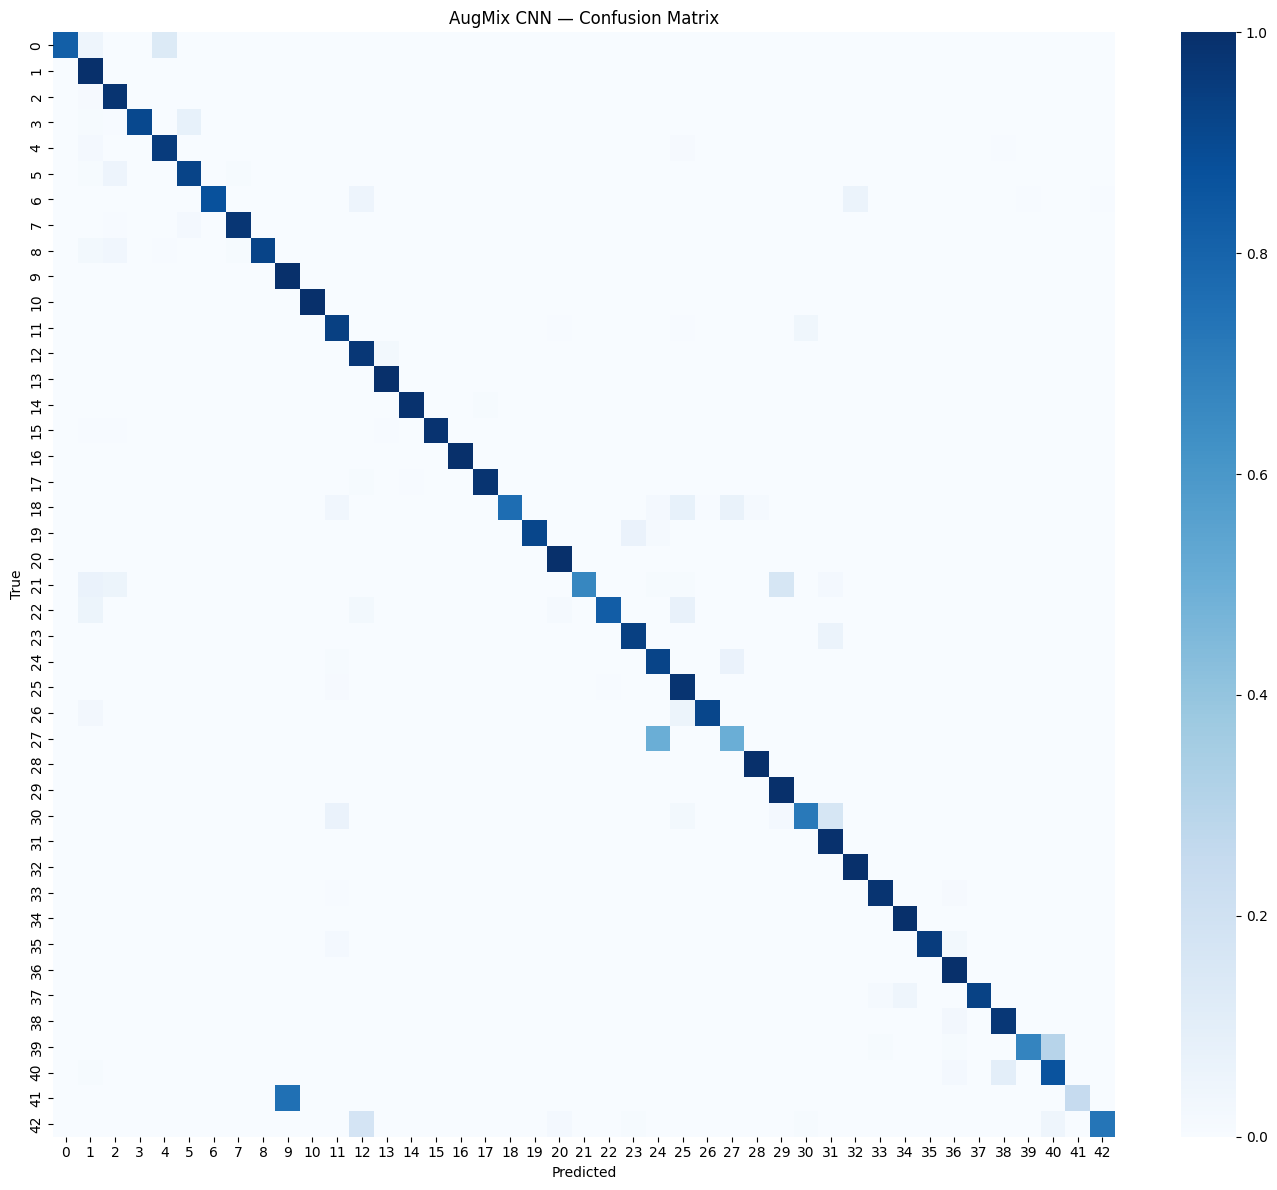

In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

criterion = nn.CrossEntropyLoss()

# ─── 1. Clean test accuracy ───────────────────────────────────────────────────
_, mlp_test    = eval_epoch(mlp_model,  test_loader, criterion)
_, cnn_test    = eval_epoch(cnn_model,  test_loader, criterion)
_, augmix_test = eval_epoch(augmix_cnn, test_loader, criterion)

print('=== Final Test Accuracy ===')
print(f'  MLP        : {mlp_test*100:.2f}%')
print(f'  CNN        : {cnn_test*100:.2f}%')
print(f'  AugMix CNN : {augmix_test*100:.2f}%')

# ─── 2. Adversarial test accuracy ─────────────────────────────────────────────
cnn_adv    = eval_adversarial(cnn_model,  test_loader, epsilon=0.03, alpha=0.003, steps=10)
augmix_adv = eval_adversarial(augmix_cnn, test_loader, epsilon=0.03, alpha=0.003, steps=10)

print('\n=== I-FGSM Test Accuracy (ε=0.03) ===')
print(f'  CNN        : {cnn_adv*100:.2f}%')
print(f'  AugMix CNN : {augmix_adv*100:.2f}%')

# ─── 3. Confusion matrix (AugMix CNN) ─────────────────────────────────────────
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(device)).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(augmix_cnn, test_loader)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_norm, cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('AugMix CNN — Confusion Matrix')
plt.tight_layout()
plt.show()